# **`Inatel - C24 (Inteligência Artificial) - 2026/1`**

# <font color='green'>**Atividade 07: MLP e CNN**</font>

## <font color='#2D9CDB'>**LEIA ATENTAMENTE AS INSTRUÇÕES A SEGUIR**</font>
- Importe este notebook no [Google Colab](https://colab.research.google.com/) para resolver os exercícios;
- Consulte o material disponibilizado pelo Prof. Felipe Figueiredo para revisar os conceitos;
- Utilize os recursos disponíveis na Internet (documentações e artigos científicos) para complementar seus estudos;
- <font color='red'>**A ATIVIDADE DEVERÁ SER REALIZADA COM O [MONITOR](mailto:matheus.botelho@ges.inatel.br) EM UM DOS SEGUINTES HORÁRIOS:**</font>

| Monitor                       | Dia           | Hora                               | Local           |
|-------------------------------|---------------|------------------------------------|---------------- |
| Matheus Botelho Sampaio Netto | Terça-feira   | <font color='orange'>17:30</font>  | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Quinta-feira  | <font color='orange'>17:30</font>  | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Sábado        | <font color='#2D9CDB'>10:00</font> | Teams (ao vivo) |
| Matheus Botelho Sampaio Netto | Sábado        | <font color='#2D9CDB'>13:30</font> | Teams (ao vivo) |

- <font color='red'>**NÃO**</font> remova as células de Código já presentes neste notebook;
- <font color='red'>**NÃO**</font> modifique as células de Markdown (em <font color='green'>verde</font> ou <font color='#2D9CDB'>azul</font>) presentes neste notebook;
- Após cada questão, há uma célula para você implementar e responder a questão;
- É permitido adicionar mais células (de código ou markdown) antes da próxima pergunta;
- Caso precise utilizar bibliotecas que não estão instaladas nativamente no Colab, inclua uma célula de código com o comando de instalação.</font>
  - Exemplo: `!pip install nome_da_biblioteca`
- <font color='red'>**Renomeie os termos `LL` para `sua_turma_de_laboratorio` e `MMMM` para `seu_numero_de_matricula` no nome do arquivo.**</font>
  - Exemplo: `C24_2026_1_L1_Atividade_07_1234.ipynb`)
- <font color='magenta'>**Faça download do notebook com a resolução no Google Colab, mantendo a saída de todas as células, e anexe-o à tarefa do Teams.**</font>

# <font color='green'><u><b>Preparação</b></u></font>

In [28]:
!pip install tensorflow numpy matplotlib seaborn scikit-learn

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

tf.random.set_seed(42)
np.random.seed(42)

# <font color='green'><u><b>Parte 1 - Conjunto de Dados</b></u></font>

Não altere o conteúdo da célula a seguir!

In [30]:
# Carregando o dataset CIFAR-10
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Ajustando dimensões dos rótulos
y_train = y_train.reshape(-1,)
y_test = y_test.reshape(-1,)

# Separando validação do treino
x_train, x_val, y_train, y_val = train_test_split(
    x_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

# Classes do dataset
class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

### <font color='#2D9CDB'>Q1) O dataset CIFAR-10 é amplamente utilizado em problemas de visão computacional e classificação de imagens. Pesquise brevemente sobre o dataset e descreva, em um único parágrafo, o domínio de aplicação da base de dados, o objetivo para o qual ela foi criada, o tipo de imagens que ela contém, a quantidade de classes existentes e alguns exemplos de objetos presentes nas imagens.</font>

O CIFAR-10 é um dataset de referência em visão computacional com o objetivo de servir como para avaliação de algoritmos de classificação de imagens. A base contém imagens coloridas de baixa resolução (32×32 pixels), divididas igualmente em 10 classes com 6.000 imagens cada, totalizando 50.000 imagens para treino e 10.000 para teste. As classes representam objetos do mundo real, como avião, automóvel, pássaro, gato, cervo, cachorro, sapo, cavalo, navio e caminhão. Seu domínio de aplicação abrange tarefas de reconhecimento e classificação de imagens, sendo utilizado para treinar e comparar modelos de redes neurais convolucionais (CNNs) e outras arquiteturas.

### <font color='#2D9CDB'>Q2) Exiba as dimensões dos conjuntos de treinamento, validação e teste, o formato das imagens, as dimensões dos vetores de rótulos e os valores únicos da variável alvo. Com base nos resultados obtidos, responda quantas imagens existem nos conjuntos de treinamento, validação e teste, qual é a resolução das imagens, quantos canais cada imagem possui e quantas classes diferentes existem no dataset.</font>

In [31]:
for conjunto in ([x_train, y_train], [x_val, y_val]):
    print(conjunto[0].shape, conjunto[1].shape)
    print(conjunto[0][0].shape, conjunto[1][0])
    print(np.unique(conjunto[1]))
    print()

print(f"Total de imagens em cada conjunto")
print(f"Treinamento: {x_train.shape[0]}")
print(f"Validação: {x_val.shape[0]}")
print(f"Teste: {x_test.shape[0]}")

(40000, 32, 32, 3) (40000,)
(32, 32, 3) 6
[0 1 2 3 4 5 6 7 8 9]

(10000, 32, 32, 3) (10000,)
(32, 32, 3) 2
[0 1 2 3 4 5 6 7 8 9]

Total de imagens em cada conjunto
Treinamento: 40000
Validação: 10000
Teste: 10000


Total de imagens em cada conjunto
Treinamento: 40000
Validação: 10000
Teste: 10000

A resolução das imagens é de 32pixels, possuindo 3 canais cada.

O total de classes que existem no dataset é 9 classes

### <font color='#2D9CDB'>Q3) Plote as primeiras 25 imagens do conjunto de treinamento utilizando a função imshow, exibindo também o nome da classe correspondente a cada imagem. Organize as imagens em uma grade 5×5 e remova os eixos para melhorar a visualização. Em seguida, analise visualmente o dataset e discuta se as imagens parecem simples ou complexas para classificação, quais características tornam o problema mais desafiador e se existem classes visualmente semelhantes.</font>

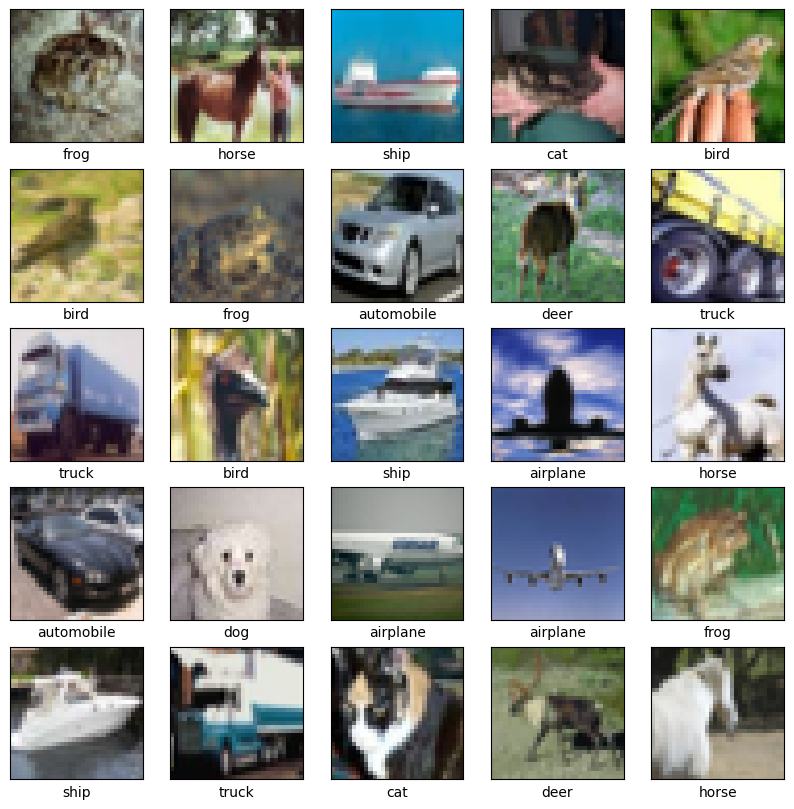

In [32]:
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5,5, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i])
    plt.xlabel(class_names[y_train[i]])
plt.show()

No geral, as imagens podem ser consideradas simples para classificar, porém o desafio que as torna complexas é a qualidade da resolução de cada uma, que é extremamente baixa podendo dificultar o aprendizado do modelo para a classificação, além da semelhança em classes como gatos, cachorros, pelos seus próprios traços físicos e características, assim como cavalo e cervo.

### <font color='#2D9CDB'>Q4) Plote a distribuição das classes do conjunto de treinamento utilizando um gráfico de barras. Com base no gráfico obtido, analise se o dataset é balanceado ou desbalanceado, compare a quantidade de amostras entre as classes e discuta se o balanceamento das classes pode impactar o treinamento e o desempenho de uma rede neural.</font>

/tmp/ipykernel_3725/2142450525.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, palette='viridis', edgecolor='black')


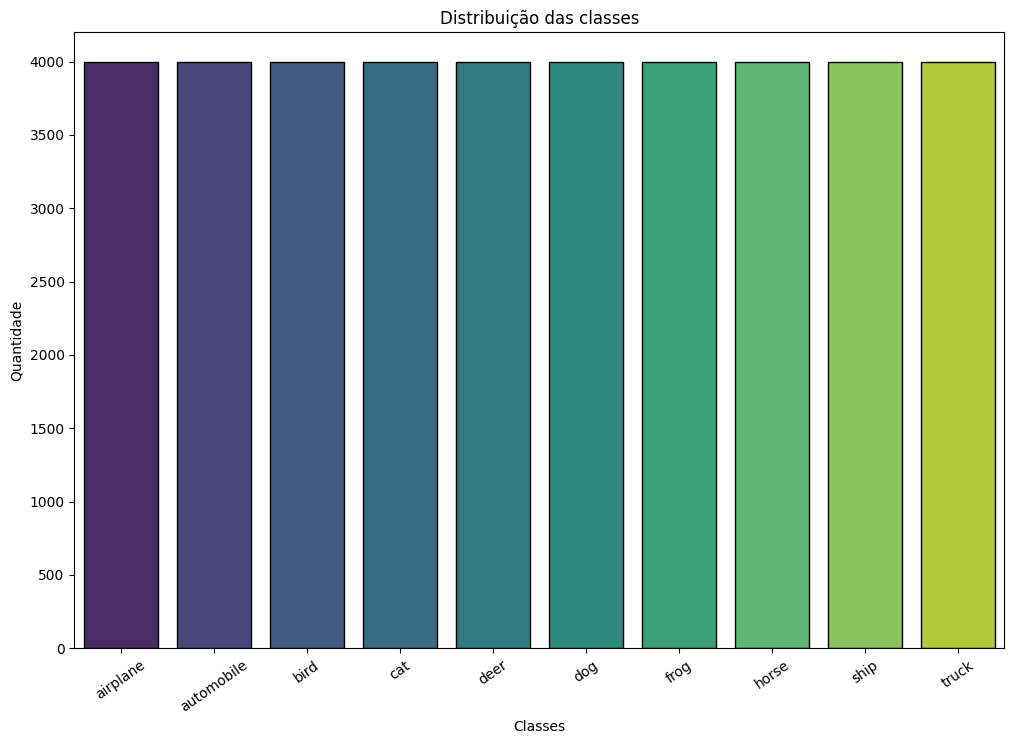

In [33]:
plt.figure(figsize=(12,8))
sns.countplot(x=y_train, palette='viridis', edgecolor='black')
plt.title("Distribuição das classes")
plt.xlabel("Classes")
plt.ylabel("Quantidade")
plt.xticks(rotation=35, ticks=range(len(class_names)), labels=class_names)
plt.show()

Dado o gráfico de barras, o dataset se apresenta bem equilibrado possuindo a mesma quantidade de classes para todas as classes, indicando uma boa quantidade de dados para o treinamento do modelo, de modo a evitar confusões com classes de baixas amostras em relação às de maior amostragem.

### <font color='#2D9CDB'>Q5) Verifique os valores mínimo e máximo dos pixels das imagens do conjunto de treinamento. Em seguida, normalize os conjuntos de treino, validação e teste dividindo os valores dos pixels por 255. Após a normalização, verifique novamente os valores mínimo e máximo e explique por que esse procedimento é importante para o treinamento de redes neurais profundas. Discuta também como a normalização influencia a estabilidade numérica do treinamento e a velocidade de convergência do algoritmo de otimização.</font>

In [34]:
print(f"Valores mínimo e máximo antes da normalização")
print(f"Treinamento: {np.min(x_train)}, {np.max(x_train)} ")
print(f"Validação: {np.min(x_val)}, {np.max(x_val)}")

x_train = x_train / 255
x_val = x_val / 255
x_test = x_test / 255

print(f"\nValores mínimo e máximo após a normalização")
print(f"Treinamento: {np.min(x_train)}, {np.max(x_train)}")
print(f"Validação: {np.min(x_val)}, {np.max(x_val)}")

Valores mínimo e máximo antes da normalização
Treinamento: 0, 255 
Validação: 0, 255

Valores mínimo e máximo após a normalização
Treinamento: 0.0, 1.0
Validação: 0.0, 1.0


É importante pois valores muito grandes na entrada da rede podem gerar gradientes instáveis durante o treinamento, causando problemas como gradientes explosivos ou dificuldade de convergência. Com os dados normalizados o otimizador dá passos mais estáveis e converge mais rapidamente. Além disso, manter todos os canais de cor (R, G, B) na mesma escala evita que o modelo trate algum canal como mais importante simplesmente por ter valores numericamente maiores, tornando o aprendizado mais equilibrado. Vale ressaltar que a normalização não altera a informação visual das imagens, apenas transforma sua representação numérica para um formato mais adequado ao treinamento de redes neurais profundas.

### <font color='#2D9CDB'>Q6) Explique por que as imagens do CIFAR-10 podem ser representadas como tensores tridimensionais. Em seguida, identifique o significado de cada dimensão do tensor (32, 32, 3), explique o papel dos canais RGB e discuta a diferença entre imagens coloridas e imagens em tons de cinza no contexto de redes neurais convolucionais.</font>

As dimensões das imagens indicam 32 pixels x 32pixels, sendo as dimensões físicas altura x largura, e 3 canais de cores, no caso RGB. O papel do canal RGB é combinar os 3 espectros de cor (R - red, G - green e  B - blue) combinando 3 imagens diferentes em cada canal para que a imagem completa e colorida seja criada.

Para uma imagem colorida, que possui os 3 canais de cores, a quantidade de filtros da rede neural precisa passar pelos 3 canais, tensor (32,32,3), ou seja, resultando em um maior custo operacional, mais parâmetros para serem aprendidos, porém com o benefício de não perder a informação das cores. Enquanto em uma imagem em tons de cinza, que só possui 1 canal, tensor (32,32,1), ocorreria o inverso, apenas perdendo a informação de cor.

# <font color='green'><u><b>Parte 2 - MLP</b></u></font>

### <font color='#2D9CDB'>Q7) As redes neurais do tipo Multilayer Perceptron (MLP) utilizam camadas densamente conectadas e, portanto, esperam vetores unidimensionais como entrada. Explique por que é necessário transformar as imagens do CIFAR-10 antes de utilizá-las em uma MLP e discuta o que acontece com a estrutura espacial das imagens durante esse processo. Em seguida, construa uma rede neural MLP utilizando a API Sequential do Keras com uma camada Flatten, duas camadas densas escondidas com função de ativação ReLU e uma camada de saída com 10 neurônios e ativação Softmax.</font>

In [35]:
tf.keras.backend.clear_session() # Limpa o coiso do modelo anterior

model = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(32,32,3)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


É necessário transformar as imagens do CIFAR-10 pois as imagens são um tensor 3D, para isso utilizamos uma camada de achatamento que as transformam. Já que cada a camada densa conecta cada neurônio de entrada a um neurônio da próxima camada, o que faz com que seja necessário transformá-los em um vetor vetor unidimensional.

### <font color='#2D9CDB'>Q8) Exiba o resumo da arquitetura da rede neural criada utilizando o método summary() e analise a quantidade de parâmetros treináveis da MLP. Com base nas dimensões das imagens do CIFAR-10 e no número de neurônios utilizados nas camadas densas, discuta por que MLPs podem rapidamente se tornar modelos muito grandes para problemas de classificação de imagens.</font>

In [36]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       393,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 411,146 (1.57 MB)

 Trainable params: 411,146 (1.57 MB)

 Non-trainable params: 0 (0.00 B)

aS MLPs terndem a se tornarem modelos muito grandes pois, por exemplo, a entrada após o achatamento possui 3072 valores, onde cada um dos 128 neurônios da camada seguinte se conecta a cada um destes valores de entrada. Este exemplo já parece grande, porém ao analisar que as imagens do CIFAR-10 são pequenas, de 32x32, ao utilizar com imagens reais o modelo tende a escalar ainda mais.

### <font color='#2D9CDB'>Q9) Compile a MLP utilizando o otimizador Adam com taxa de aprendizado de $10^{-3}$, a função de custo sparse_categorical_crossentropy e a métrica accuracy. Em seguida, explique o papel da função de custo durante o treinamento, o objetivo do algoritmo de otimização e por que a combinação entre Softmax e entropia cruzada é adequada para problemas de classificação multiclasse.</font>

In [37]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.sparse_categorical_crossentropy,
    metrics=['accuracy']
)

A função de custo  mede o erro entre a distribuição de probabilidades prevista pelo modelo e o rótulo real de cada amostra durante o treinamento. Seu objetivo é penalizar predições incorretas, guiando os pesos da rede na direção que minimiza esse erro a cada iteração.
O otimizador atua ajustando a taxa de aprendizado de forma adaptativa para cada parâmetro. Com a taxa de aprendizado definida em 1e-3, ele atualiza os pesos da rede de maneira eficiente, buscando minimizar a função de custo ao longo das épocas de treinamento.

A combinação entre Softmax e entropia cruzada é especialmente adequada para classificação multiclasse pois a Softmax transforma as saídas da rede em probabilidades que somam 1, atribuindo uma probabilidade para cada uma das 10 classes. A entropia cruzada, por sua vez, penaliza fortemente quando o modelo atribui baixa probabilidade à classe correta, forçando o modelo a ser cada vez mais confiante nas predições corretas. Juntas, essas duas funções formam uma combinação matematicamente conveniente, pois o gradiente resultante é simples facilitando o aprendizado da rede.

### <font color='#2D9CDB'>Q10) Treine a rede neural por 25 épocas utilizando os conjuntos de treinamento e validação. Armazene o histórico do treinamento em um objeto do tipo History e, em seguida, plote gráficos mostrando a evolução da loss e da accuracy ao longo das épocas para os conjuntos de treinamento e validação. Após gerar os gráficos, analise o comportamento do treinamento, discutindo se o modelo aparenta convergir adequadamente, se há estabilidade durante o treinamento e se existem indícios de overfitting.</font>

In [38]:
history = model.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    epochs=25
)

Epoch 1/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.3213 - loss: 1.8821 - val_accuracy: 0.3324 - val_loss: 1.8624
Epoch 2/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3801 - loss: 1.7187 - val_accuracy: 0.3841 - val_loss: 1.7275
Epoch 3/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4093 - loss: 1.6419 - val_accuracy: 0.3983 - val_loss: 1.6750
Epoch 4/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4273 - loss: 1.5890 - val_accuracy: 0.4166 - val_loss: 1.6313
Epoch 5/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4428 - loss: 1.5499 - val_accuracy: 0.4312 - val_loss: 1.6045
Epoch 6/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4552 - loss: 1.5207 - val_accuracy: 0.4451 - val_loss: 1.5810
Epoch 7/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4607 - loss: 1.5002 - val_accuracy: 0.4562 - val_loss: 1.5620
Epoch 8/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4701 - loss: 1.4784 -

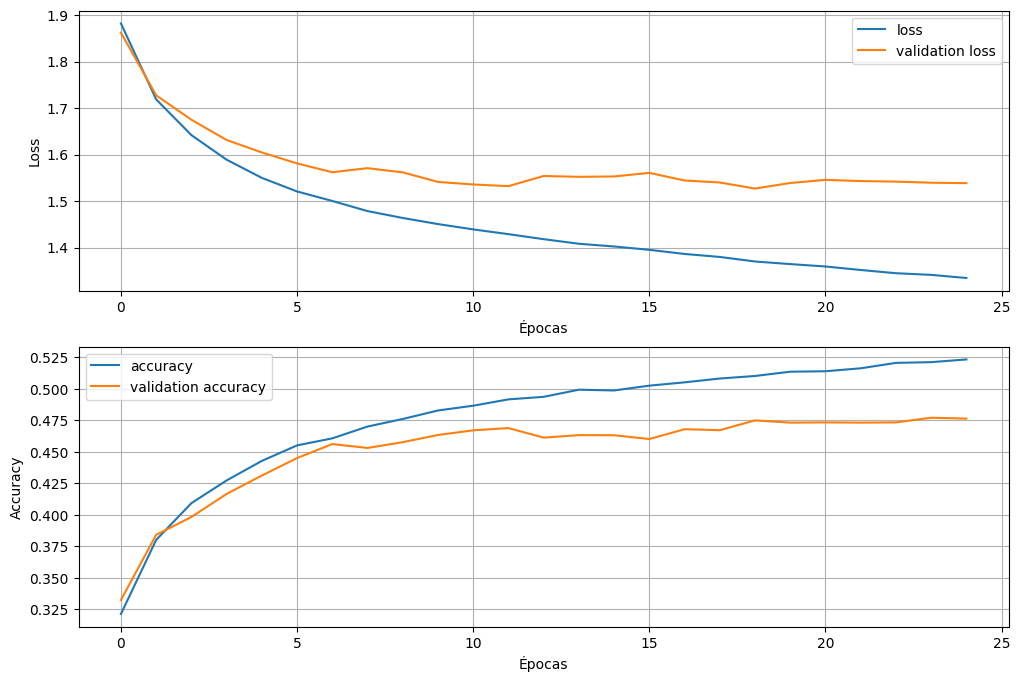

In [39]:
# Lembrar de melhorar esse plot aqui

plt.figure(figsize=(12,8))

plt.subplot(2,1,1)
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='validation loss')

plt.legend()
plt.grid(True)
plt.xlabel("Épocas")
plt.ylabel("Loss")

plt.subplot(2,1,2)
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='validation accuracy')

plt.legend()
plt.grid(True)
plt.xlabel("Épocas")
plt.ylabel("Accuracy")

plt.show()

Observando o treinamento, nota-se que o modelo tende a convergir para um valor para accuracy e loss, embora este valor seja insatisfatório, o que pode indicar princípios de underfitting, dado que o modelo não capturou bem as características dos dados, tanto no conjunto de treinamento quanto no conjunto de validação.

### <font color='#2D9CDB'>Q11) Avalie o desempenho da MLP utilizando o conjunto de teste e reporte os valores de loss e accuracy obtidos. Em seguida, compare os resultados dos conjuntos de treinamento e teste e discuta se o modelo aparenta apresentar boa capacidade de generalização.</font>

In [40]:
loss_evaluate, acc_evaluate = history.model.evaluate(x_test, y_test)

print(f"Resultados com evaluate utilizando o conjunto de teste")
print(f"\nLoss: {loss_evaluate:.4f}")
print(f"Accuracy: {acc_evaluate:.4f}")

print(f"\nResultados do treinamento sem evaluate (treinamento e validação)")
print(f"\nLoss: {history.history['loss'][-1]:.4f}")
print(f"Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"\nLoss: {history.history['val_loss'][-1]:.4f}")
print(f"Accuracy: {history.history['val_accuracy'][-1]:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4709 - loss: 1.5281
Resultados com evaluate utilizando o conjunto de teste

Loss: 1.5281
Accuracy: 0.4709

Resultados do treinamento sem evaluate (treinamento e validação)

Loss: 1.3345
Accuracy: 0.5234

Loss: 1.5385
Accuracy: 0.4764


Comparando e analisando os resultados das métricas de loss e accuracy pode-se inferir que o modelo não tem capacidade para capturar a complexidade dos dados, já que seus valores de acurácia estão no entorno de 0.50, um valor muito baixo, tanto para a avaliação com conjunto de teste, que apresentou resultados ainda levemente menores do que os resultados de treinamento e validação. Além disso o modelo ainda se demonstra consistente em seguir esse valor nos conjuntos de validação e teste, o que pode indicar um Underfitting nos dados, visto que o modelo não consegue capturar os padrões nas imagensm, demonstrado pelos resultados baixos.

### <font color='#2D9CDB'>Q12) Utilize a MLP treinada para gerar previsões sobre algumas imagens do conjunto de teste. Exiba as probabilidades previstas para cada classe, identifique a classe predita pelo modelo e compare-a com a classe verdadeira da imagem. Com base nas probabilidades obtidas, explique o significado da saída Softmax e discuta se o modelo está realizando previsões com alta ou baixa confiança.</font>

In [41]:
!pip install pandas

In [42]:
import pandas as pd

df = pd.DataFrame(np.round(model.predict(x_test[:20]),6), columns=class_names)
df.insert(0, "Classe", [class_names[i] for i in y_test[:20]])

# Adicionando ao dataframe uma coluna com a classe predita
df.insert(11, "Classe predita", [class_names[i] for i in (np.argmax(model.predict(x_test[:20]), axis=1))])

display(df)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


,Classe,airplane,automobile,bird,cat,deer,dog,frog,horse,ship,truck,Classe predita
0,cat,0.006200,0.100116,0.005169,0.654694,0.006159,0.151191,0.013530,0.001634,0.011809,0.049498,cat
1,ship,0.029094,0.158920,0.000068,0.000014,0.000068,0.000006,0.000010,0.000036,0.688918,0.122865,ship
2,ship,0.141229,0.163595,0.001553,0.000282,0.002150,0.000532,0.000100,0.000970,0.468171,0.221418,ship
3,airplane,0.059051,0.042891,0.138984,0.063441,0.123113,0.057879,0.001365,0.035361,0.432173,0.045742,ship
4,frog,0.001273,0.000246,0.048134,0.041241,0.469154,0.030408,0.397080,0.008625,0.003305,0.000535,deer
5,frog,0.000482,0.010387,0.009994,0.417135,0.000926,0.173698,0.378651,0.002882,0.000001,0.005844,cat
6,automobile,0.005760,0.859739,0.000721,0.072283,0.000164,0.042915,0.001970,0.000379,0.005009,0.011058,automobile
7,frog,0.000946,0.001418,0.036971,0.024631,0.011546,0.017711,0.905220,0.000403,0.000209,0.000945,frog
8,cat,0.022435,0.001374,0.208271,0.187938,0.225682,0.238305,0.052188,0.052736,0.009292,0.001780,dog
9,automobile,0.020690,0.491776,0.026141,0.013423,0.005589,0.005616,0.001817,0.002881,0.060021,0.372046,automobile


/

### <font color='#2D9CDB'>Q13) Plote a matriz de confusão da MLP utilizando o conjunto de teste. Em seguida, identifique quais classes foram mais confundidas pelo modelo e discuta possíveis razões para esses erros de classificação, considerando as limitações de uma arquitetura MLP aplicada a problemas de visão computacional.</font>

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


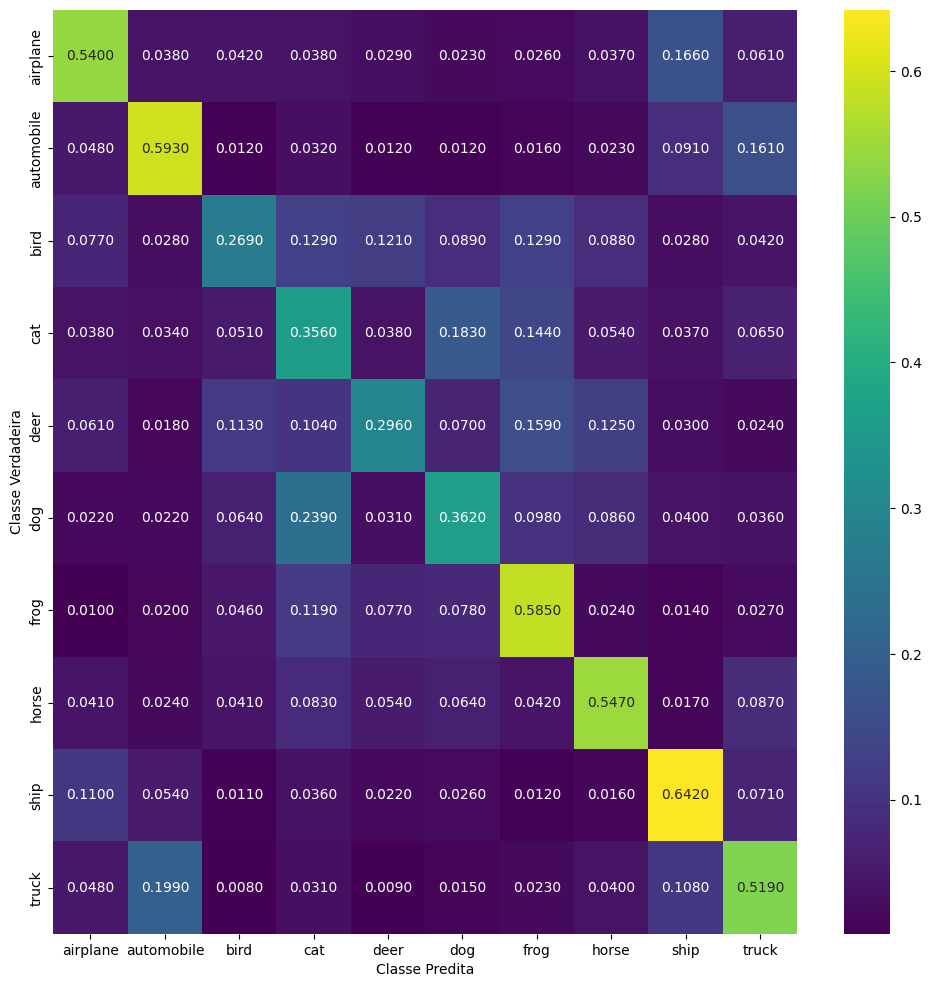

In [43]:
plt.figure(figsize=(12,12))

y_pred = np.argmax(model.predict(x_test), axis=1)
cm = confusion_matrix(y_test, y_pred, normalize='true')

sns.heatmap(cm, annot=True, cmap='viridis', fmt='.4f', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Classe Predita")
plt.ylabel("Classe Verdadeira")
plt.show()


Um dos possíveis problemas que geram esse erro grande para a predição no modelo MLP, é a perda da informação espacial de cada imagem, devido à necessidade de achatar as imagens em um vetor unidimensional. Em problemas de visão computacional essa informação é vital, de forma que o modelo deva ser capaz de localizar a posição da predição que este tenha feito, algo que simplesmente não é possível de se fazer em uma MLP.

### <font color='#2D9CDB'>Q14) Com base nos resultados obtidos ao longo desta etapa, discuta as principais vantagens e limitações das redes MLP para classificação de imagens. Em sua resposta, considere aspectos como preservação da estrutura espacial das imagens, quantidade de parâmetros treináveis, capacidade de generalização e desempenho obtido no CIFAR-10.</font>

Ao utilizar uma rede MLP para a classificação de imagens, observa-se que uma de suas principais desvantagens é a perda da informação espacial, visto que é necessário comprimir a imagem em tensor 3D para um array unidimensional. Com esta perda de informações, o modelo seguiu uma tendência para o underfitting, não conseguindo capturar os padrões dos dados corretamente. Entretanto, este modelo tende a ser mais rápido para o treinamento em relação a um CNN.

# <font color='green'><u><b>Parte 3 - CNN</b></u></font>

### <font color='#2D9CDB'>Q15) As redes neurais convolucionais (CNNs) foram desenvolvidas para lidar melhor com dados que possuem estrutura espacial, como imagens. Explique por que arquiteturas MLP apresentam limitações em problemas de visão computacional e descreva como as CNNs conseguem preservar relações espaciais entre os pixels. Em seguida, explique os conceitos de convolução, filtros convolucionais e mapas de características (feature maps).</font>

MLPs apresentam limitações em visão computacional pois transformam a imagem em um vetor unidimensional, perdendo toda a estrutura espacial dos pixels. Isso significa que a relação entre pixels vizinhos, como bordas, texturas e formas, deixa de existir para o modelo, dificultando o reconhecimento de padrões visuais.

As CNNs resolvem esse problema ao aplicar filtros convolucionais diretamente sobre a estrutura bidimensional da imagem, preservando as relações espaciais entre os pixels. A convolução consiste em deslizar um filtro, uma pequena matriz de pesos, sobre a imagem, realizando multiplicações e somando os resultados para gerar um novo valor de saída. Cada filtro é treinado para detectar um padrão específico, como bordas horizontais, verticais ou texturas. O resultado desse processo é chamado de mapa de características (feature map), que representa onde e com que intensidade determinado padrão foi detectado na imagem. Ao empilhar várias camadas convolucionais, a rede aprende padrões cada vez mais complexos, partindo de bordas simples nas primeiras camadas até formas e objetos completos nas camadas mais profundas.

### <font color='#2D9CDB'>Q16) Construa uma rede neural convolucional utilizando a API Sequential do Keras. A arquitetura da CNN deve conter camadas Conv2D com ativação ReLU, camadas MaxPooling2D, uma camada Flatten e uma camada de saída com 10 neurônios e ativação Softmax. Após construir a arquitetura, explique o papel das camadas convolucionais, das camadas de pooling e da camada Flatten dentro da CNN.</font>

In [44]:
tf.keras.backend.clear_session() # Limpa o coiso do modelo anterior

model_cnn = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(32,32,3)),
    tf.keras.layers.Conv2D(activation='relu', filters=32, kernel_size=(3,3)),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(activation='relu', filters=64, kernel_size=(3,3)),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])


As camadas Conv2D são responsáveis por extrair padrões visuais da imagem aplicando filtros convolucionais sobre a entrada. Na primeira camada, 32 filtros detectam padrões simples como bordas e texturas, enquanto na segunda camada, 64 filtros combinam esses padrões para identificar formas mais complexas. A ativação ReLU é aplicada após cada convolução para introduzir não-linearidade ao modelo.

As camadas MaxPooling2D reduzem a dimensão espacial dos mapas de características pela metade, selecionando o valor máximo em cada janela 2x2. Isso diminui o custo computacional, reduz o risco de overfitting e torna o modelo mais robusto a pequenas variações de posição dos padrões na imagem.

A camada Flatten transforma os mapas de características bidimensionais em um vetor unidimensional, conectando a parte convolucional da rede às camadas Dense finais. Essas camadas densas combinam as características extraídas para realizar a classificação, culminando na camada de saída com 10 neurônios e ativação Softmax, que atribui uma probabilidade para cada classe do CIFAR-10.

### <font color='#2D9CDB'>Q17) Exiba o resumo da arquitetura da CNN utilizando o método summary() e compare a quantidade de parâmetros treináveis da CNN com a da MLP construída anteriormente. Em seguida, discuta por que CNNs costumam ser mais eficientes para classificação de imagens, mesmo utilizando menos parâmetros treináveis.</font>

In [45]:
model_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 350,026 (1.34 MB)

 Trainable params: 350,026 (1.34 MB)

 Non-trainable params: 0 (0.00 B)

A CNN apresenta um total de 350 mil parâmetros treináveis, significativamente menor do que a MLP anterior, que chega a mais de 400 mil.. Essa diferença se deve ao compartilhamento de pesos nas camadas convolucionais, onde o mesmo filtro é aplicado em toda a imagem, ao invés de conectar cada pixel a cada neurônio como a MLP faz.

Observando o summary, é possível ver que as camadas Conv2D concentram poucos parâmetros, enquanto a maior parte dos parâmetros está nas camadas Dense, justamente onde a estrutura espacial já foi perdida. Isso reforça que a parte convolucional extrai padrões de forma muito eficiente com poucos pesos, enquanto as camadas densas são responsáveis pela classificação final.
CNNs costumam ser mais eficientes para imagens pois exploram a estrutura espacial dos dados, aprendendo padrões que se repetem em diferentes regiões da imagem com os mesmos filtros. Isso reduz a quantidade de parâmetros necessários e  torna o modelo mais capaz de generalizar para imagens não vistas durante o treinamento.

### <font color='#2D9CDB'>Q18) Compile a CNN utilizando o otimizador Adam com taxa de aprendizado de $10^{-3}$, a função de custo sparse_categorical_crossentropy e a métrica accuracy. Em seguida, treine o modelo por até 25 épocas utilizando os conjuntos de treinamento e validação. Armazene o histórico do treinamento em um objeto do tipo History. Após o treinamento, plote gráficos mostrando a evolução da loss e da accuracy ao longo das épocas para os conjuntos de treinamento e validação e analise o comportamento do treinamento da CNN.</font>

In [46]:
model_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.sparse_categorical_crossentropy,
    metrics=['accuracy']
)

In [47]:
history_cnn = model_cnn.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    batch_size=32,
    epochs=25
)

Epoch 1/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.4613 - loss: 1.4701 - val_accuracy: 0.5843 - val_loss: 1.1813
Epoch 2/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6094 - loss: 1.1005 - val_accuracy: 0.6389 - val_loss: 1.0387
Epoch 3/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.6679 - loss: 0.9409 - val_accuracy: 0.6616 - val_loss: 0.9906
Epoch 4/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7104 - loss: 0.8237 - val_accuracy: 0.6725 - val_loss: 0.9758
Epoch 5/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.7447 - loss: 0.7296 - val_accuracy: 0.6626 - val_loss: 1.0119
Epoch 6/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7747 - loss: 0.6459 - val_accuracy: 0.6600 - val_loss: 1.0808
Epoch 7/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.7989 - loss: 0.5751 - val_accuracy: 0.6603 - val_loss: 1.1349
Epoch 8/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8168 - loss: 0.5138 

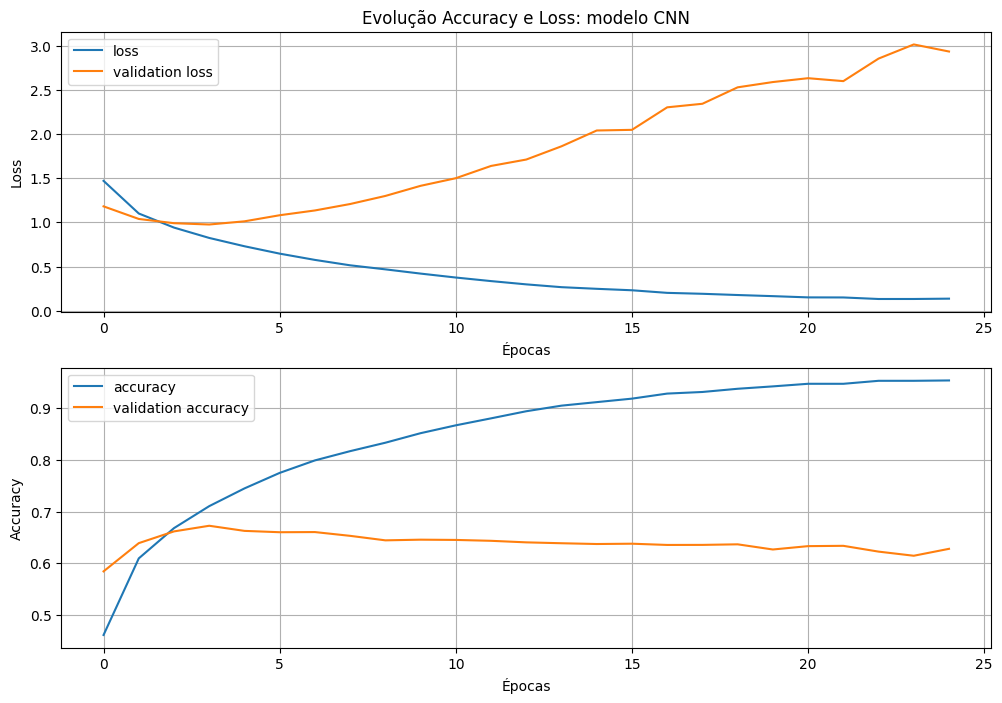

In [48]:
plt.figure(figsize=(12,8))

plt.subplot(2,1,1)
plt.title("Evolução Accuracy e Loss: modelo CNN")
plt.plot(history_cnn.history['loss'], label='loss')
plt.plot(history_cnn.history['val_loss'], label='validation loss')

plt.legend()
plt.grid(True)
plt.xlabel("Épocas")
plt.ylabel("Loss")

plt.subplot(2,1,2)
plt.plot(history_cnn.history['accuracy'], label='accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='validation accuracy')

plt.legend()
plt.grid(True)
plt.xlabel("Épocas")
plt.ylabel("Accuracy")

plt.show()

Observando os gráficos, é possível identificar um claro caso de overfitting. A loss de treinamento cai continuamente ao longo das 25 épocas, chegando próximo de 0, enquanto a validation loss aumenta progressivamente após a época 3, indicando que o modelo passou a memorizar os dados de treino ao invés de generalizar.
O mesmo comportamento é visível na accuracy: o modelo atinge cerca de 95% de acurácia no treino, enquanto a validação estabiliza em torno de 65% já nas primeiras épocas e não apresenta melhora significativa. Essa divergência entre treino e validação é a principal evidência de overfitting.
Para mitigar esse problema, algumas estratégias poderiam ser aplicadas, como adicionar camadas de Dropout, utilizar regularização L2 ou utilizar Early Stopping para interromper o treinamento no ponto de menor validation loss.

### <font color='#2D9CDB'>Q19) Avalie o desempenho da CNN utilizando o conjunto de teste e compare os resultados obtidos com aqueles alcançados pela MLP. Em seguida, discuta as diferenças observadas em termos de accuracy, capacidade de generalização e aprendizado de características visuais.</font>

In [49]:
loss_cnn, acc_cnn = model_cnn.evaluate(x_test, y_test)

print(f"Resultados com evaluate utilizando o conjunto de teste")
print(f"\nLoss: {loss_cnn:.4f}")
print(f"Accuracy: {acc_cnn:.4f}")

print(f"\nResultados do treinamento sem evaluate (treinamento e validação)")
print(f"\nLoss: {history.history['loss'][-1]}")
print(f"Accuracy: {history_cnn.history['accuracy'][-1]}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6366 - loss: 2.9511
Resultados com evaluate utilizando o conjunto de teste

Loss: 2.9511
Accuracy: 0.6366

Resultados do treinamento sem evaluate (treinamento e validação)

Loss: 1.334494948387146
Accuracy: 0.9535250067710876


A CNN obteve 64,36% de accuracy no conjunto de teste, com uma loss de 2.74, enquanto no treinamento atingiu 95,92% de accuracy. Essa grande diferença confirma o overfitting identificado nos gráficos da questão anterior, onde o modelo aprendeu a memorizar os dados de treino mas não generalizou bem para dados novos.
Comparando com a MLP, a CNN apresenta resultados similares, com um desempenho maio-r no conjunto de treinamento e, apesar do overfitting identificado, um desempenho melhor também no teste, o que não significa que CNNs sejam necessariamente melhores ou piores devido ao overfitting, mas sim que o modelo atual precisaria de técnicas de regularização para atingir seu potencial real. Em condições ideais, CNNs tendem a superar MLPs em tarefas de visão computacional justamente por preservarem a estrutura espacial das imagens e aprenderem características visuais hierárquicas, como bordas, texturas e formas, ao invés de tratar cada pixel de forma independente como a MLP faz.

### <font color='#2D9CDB'>Q20) Utilize a CNN treinada para gerar previsões sobre algumas imagens do conjunto de teste. Exiba as probabilidades previstas para cada classe, identifique a classe predita e compare-a com a classe verdadeira da imagem. Em seguida, analise se a CNN aparenta realizar previsões mais confiantes que a MLP e discuta possíveis razões para esse comportamento.</font>

In [50]:
df_cnn = pd.DataFrame(np.round(model_cnn.predict(x_test[:20]), 6), columns=class_names)

df_cnn.insert(0, "Class names", [class_names[i] for i in y_test[:20]])
df_cnn.insert(11, "Predicted class", [class_names[i] for i in (np.argmax(model_cnn.predict(x_test[:20]), axis=1))])

display(df_cnn)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


,Class names,airplane,automobile,bird,cat,deer,dog,frog,horse,ship,truck,Predicted class
0,cat,0.000000,0.000005,0.000000,0.990904,0.000000,0.009083,0.000000,0.000000,0.000001,0.000006,cat
1,ship,0.000000,0.000009,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.999991,0.000000,ship
2,ship,0.000005,0.925122,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000659,0.074214,automobile
3,airplane,0.999987,0.000004,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000009,0.000000,airplane
4,frog,0.000000,0.000000,0.000000,0.000270,0.999406,0.000019,0.000305,0.000000,0.000000,0.000000,deer
5,frog,0.000000,0.000006,0.000006,0.000133,0.000000,0.000153,0.999697,0.000000,0.000000,0.000005,frog
6,automobile,0.000000,0.998360,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001640,automobile
7,frog,0.000204,0.000000,0.003488,0.988536,0.003687,0.000864,0.003214,0.000001,0.000006,0.000000,cat
8,cat,0.000000,0.000000,0.000010,0.989874,0.000007,0.009998,0.000111,0.000001,0.000000,0.000000,cat
9,automobile,0.000000,0.981337,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.018663,automobile


Observado o dataframe (com aproximação dos valores para 6 casas decimais), nota-se que, em relação ao dataframe da probabilidades do modelo MLP, uma maior certeza no conjunto de treinamento. As probabilidades se demonstram menos espalhadas por entre as classes em cada classificação, embora a acurácia desta certeza probabilística não seja exatamente satisfatória em todos os casos observados, como na probabilidade de 87.37% de uma imagem de rótulo 'Horse' sendo classificada como 'cat'. Uma das possíveis causas para essa maior certeza, ainda que com baixa acurácia, pode ser a preservação da imagem em suas dimensões espaciais, permitindo identificação de mais características representadas no espaço onde se localiza a classe avaliada.

### <font color='#2D9CDB'>Q21) Plote a matriz de confusão da CNN utilizando o conjunto de teste e compare-a com a matriz de confusão obtida pela MLP. Identifique quais classes apresentaram melhora significativa de classificação e discuta por que CNNs conseguem reduzir confusões entre classes visualmente semelhantes.</font>

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


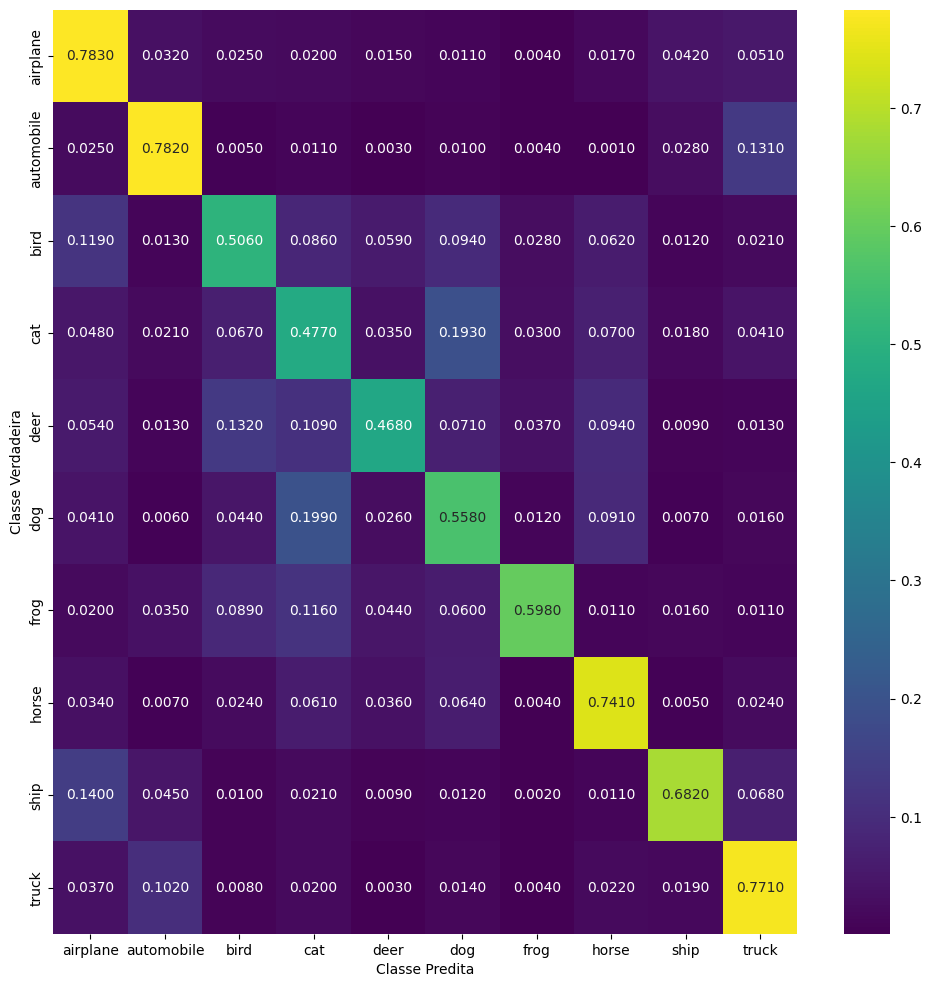

In [51]:
plt.figure(figsize=(12,12))

y_pred_cnn = np.argmax(model_cnn.predict(x_test), axis=1)
cm_cnn = confusion_matrix(y_test, y_pred_cnn, normalize='true')

sns.heatmap(cm_cnn, annot=True, cmap='viridis', fmt='.4f', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Classe Predita")
plt.ylabel("Classe Verdadeira")
plt.show()

Em comparação ao modelo MLP anterior, pode-se observar uma melhora significativa em classes como bird, deer, truck, entre outras. O que indica que o modelo consegue capturar melhor os padrões das imagens. Devido à preservação da informação visual, neste caso, a informação espacial da imagem, CNNs tendem a classificar melhor do que MLPs, que quebram a imagem em um vetor unidimensional, perdendo as informações do espaço. Um exemplo claro, poderia ser a presença de um céu azul em uma imagem de um avião, identificado pela CNN, o que pode ajudar na classificação do avião, enquanto essa informação espacial é perdida no treinamento da MLP.

Outro fator de melhora comparando ambas as saídas é o quão espalhadas as classificações, no caso da MLP, se encontravam, algo que pode ser observado com clareza na CNN que apresenta menos casos de confusão.

### <font color='#2D9CDB'>Q22) Adicione camadas Dropout à CNN e treine novamente o modelo. Em seguida, plote as curvas de loss e accuracy para os conjuntos de treinamento e validação e compare os resultados com a CNN original. Com base nos gráficos obtidos, discuta o impacto do Dropout no overfitting e na capacidade de generalização da rede neural.</font>

In [52]:
model_cnn_drop = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(32,32,3)),
    tf.keras.layers.Conv2D(activation='relu', filters=32, kernel_size=(3,3)),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(activation='relu', filters=64, kernel_size=(3,3)),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Dense(10, activation='softmax')
])

model_cnn_drop.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.sparse_categorical_crossentropy,
    metrics=['accuracy']
)

In [53]:
history_cnn_drop = model_cnn_drop.fit(
    x_train,
    y_train,
    batch_size=32,
    validation_data=(x_val, y_val),
    epochs=25
)

Epoch 1/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.4146 - loss: 1.5862 - val_accuracy: 0.5729 - val_loss: 1.2038
Epoch 2/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5670 - loss: 1.2183 - val_accuracy: 0.6209 - val_loss: 1.0761
Epoch 3/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.6235 - loss: 1.0711 - val_accuracy: 0.6559 - val_loss: 0.9988
Epoch 4/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6628 - loss: 0.9702 - val_accuracy: 0.6590 - val_loss: 0.9688
Epoch 5/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.6885 - loss: 0.8927 - val_accuracy: 0.6666 - val_loss: 0.9556
Epoch 6/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7070 - loss: 0.8348 - val_accuracy: 0.6784 - val_loss: 0.9316
Epoch 7/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.7275 - loss: 0.7811 - val_accuracy: 0.6790 - val_loss: 0.9486
Epoch 8/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.7443 - loss: 0.7352 

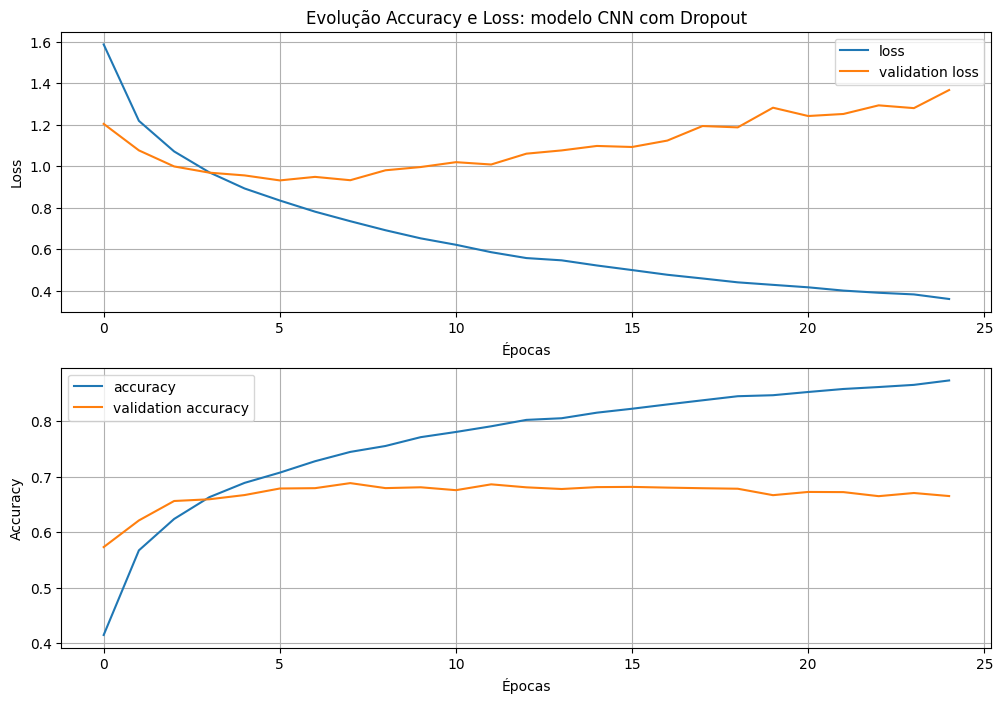

In [54]:
plt.figure(figsize=(12,8))

plt.subplot(2,1,1)
plt.title("Evolução Accuracy e Loss: modelo CNN com Dropout")
plt.plot(history_cnn_drop.history['loss'], label='loss')
plt.plot(history_cnn_drop.history['val_loss'], label='validation loss')

plt.legend()
plt.grid(True)
plt.xlabel("Épocas")
plt.ylabel("Loss")

plt.subplot(2,1,2)
plt.plot(history_cnn_drop.history['accuracy'], label='accuracy')
plt.plot(history_cnn_drop.history['val_accuracy'], label='validation accuracy')

plt.legend()
plt.grid(True)
plt.xlabel("Épocas")
plt.ylabel("Accuracy")

plt.show()

Analisando o gráfico e comparando-o com o modelo CNN anterior, observa-se que o overfitting foi mitigado, porém ainda não completamente combatido. A evolução das épocas ainda indica overfitting em ambos os gráficos, de loss e accuracy, a mudança na métrica de accuracy em relação ao modelo CNN anterior varia de aproximadamente 3% para cima, apesar de indicar uma melhora, esta ainda não é satisfatória para eliminar o overfitting do modelo.

O mesmo foi observado ao treinar o modelo com diferentes taxas de dropout, onde o resultado obtido seguiu o mesmo padrão do exemplo anterior, com a variação caindo para menos de 3% em casos de dropout com rate aproximados para 0.4%, um valor maior do que o de 0.25% utilizado.

### <font color='#2D9CDB'>Q23) Com base em todos os resultados obtidos ao longo da atividade, compare as arquiteturas MLP e CNN para classificação de imagens. Em sua resposta, discuta diferenças relacionadas à preservação da estrutura espacial das imagens, quantidade de parâmetros treináveis, capacidade de generalização, desempenho obtido no CIFAR-10 e adequação de cada arquitetura para problemas de visão computacional.</font>

Comparando os resultados obtidos para ambas as arquiteturas, o padrão observado é de que o modelo MLP não é capaz de capturar o padrão dos dados e sofre de underfitting, enquanto o modelo CNN (com e sem dropout) apresentam características de overfitting, apesar dos resultados superiores ao modelo MLP no conjunto de validação.

Isso indica que, embora ele sofra de overfitting, o modelo CNN desempenha melhor do que o MLP, assim como esperado, visto que este preserva melhor as informações espaciais dos objetos, a uma margem de 10% em média para cada época. A utilização do dropout, indicou uma melhora no conjunto de validação, embora esta tenha sido pequena, na média de 3%, mantendo uma capacidade generalização baixa para o modelo CNN.

Por fim, conclui-se que nenhum modelo obteve um desempenho satisfatório no CIFAR-10, ainda que o modelo CNN (utilizando dropout) possua desempenho melhor do que os demais modelos, MLP e CNN sem dropout. A arquitetura mais indicada para problemas de visão computacional nesse caso seria ainda o modelo CNN utilizando o dropout, dado que este é capaz de manter características importantes espaciais da imagem, uma das informações mais relevantes adequadas para esse tipo de problema.